# FEM for submerged tunnel as 3D beams

In [291]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Visualize the tunnel

- Radius = 2683 m
- Distance between landings = 3700 m
- Angular span = [68.2 deg, 111.8 deg]

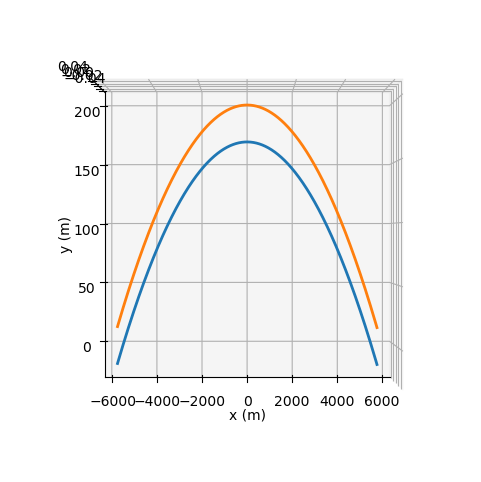

In [292]:
TunRad = 84118 #m
TunAng = (90+7.5/2, 90-7.5/2) #deg
# dth = 0.0307 #deg
dth = 7.5/880
TunCX = TunRad*np.cos( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY = TunRad*np.sin( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY = TunCY - min(TunCY)-15
TunCZ = 0*TunCX

TunCX2 = TunRad*np.cos( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY2 = TunRad*np.sin( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY2 = TunCY2 - min(TunCY2)+15
TunCZ2 = 0*TunCX2

ax = plt.axes(projection='3d')
ax.view_init(90, 270)
plt.plot(TunCX, TunCY, TunCZ, lw=2)
plt.plot(TunCX2, TunCY2, TunCZ2, lw=2)
plt.grid("on")
# plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')


TunCX = np.append(TunCX, TunCX2)
TunCY = np.append(TunCY, TunCY2)
TunCZ = np.append(TunCZ, TunCZ2)

## Properties of Beam

In [293]:
Beam_GJ = 9.5e12                 # [N.m2]
Beam_Im = 1.5e6                      #[kg.m]
Beam_m = 1.1e5                  # [kg/m]
Beam_EIy = 141193e9               # [N.m2]
Beam_EIz = 141193e9               # [N.m2]
Beam_EA = 15.5*39e9              # [N]


# Connector is 6 meters wide and 5.5 meters high, with a thickness of 0.5 meters. So inner area is 5 meters wide and 4.5 meters high
# The connector is made of the same material as the tunnel, which has a Young's modulus of 39 GPa. 
# The mass per meter of the connector is calculated based on its volume and the density of the material, which is assumed to be 2600 kg/m3.

E = 39e9                                  # Pa, Young's modulus of reinforced concrete
G = 16.3e9                                 # Pa, shear modulus of reinforced concrete
h_out = 6                                  # m, outer diameter of the connector
h_in = 5                                  # m, inner diameter of the connector
w_out = 5.5                                # m, outer width of the connector
w_in = 4.5                                # m, inner width of the connector
t=0.5
hm = 6-t
bm = 5.5-t
Am = hm*bm
pm = 2*(hm+bm)                                                  # m, perimeter of the connector cross-section
Concrete_density = 2600                                         # kg/m3, density of reinforced concrete
TunArea = 6*5.5 - 5*4.5                                         # m2, cross-sectional area of the connector
connector_GJ = G*(2*t**2 * bm**2 * hm**2/(bm+hm))                                 # [N.m2]
connector_Im = 2600* (bm**2 + hm**2)**2 * bm*hm*t / 144         #[kg.m] (Volgens mij hoort dit niet zo)
connector_m =  (TunArea) *2600                                  # [kg/m]
connector_EIy = 1/12 * (w_out**3*h_out - w_in**3*h_in) * E      # [N.m2]
connector_EIz = 1/12 * (w_out*h_out**3 - w_in*h_in**3) * E      # [N.m2]
connector_EA = (6 * 5.5 - 5 * 4.5) * E     # [N]
# connector_GJ = 2.12e13 / 2                 # [N.m2]
# connector_Im = 1.17e6 / 2                     #[kg.m]
# connector_m = 248609 / 2               # [kg/m]
# connector_EIy = 141193e9 / 2               # [N.m2]
# connector_EIz = 141193e9 / 2                   # [N.m2]
# connector_EA = (6 * 5 - 5.5 * 4.5) * 39e9     # [N]



print("Torsional rigidity (GJ) "f"{Beam_GJ:.2}"" N.m2")
print("Mass moment of inertia (Im) "f"{Beam_Im:.2}"" kg.m")
print("Mass per meter "f"{Beam_m}"" kg/m")
print("Flexural rigidity (EI_y) "f"{Beam_EIy:.2}"" N.m2")
print("Flexural rigidity (EI_z) "f"{Beam_EIz:.2}"" N.m2")
print("Axial rigidity (EA)" f"{Beam_EA:.2}" " N")

print("-" * 50)

print("Torsional rigidity connector (GJ) "f"{connector_GJ:.2}"" N.m2")
print("Mass moment of inertia connector (Im) "f"{connector_Im:.2}"" kg.m")
print("Mass per meter connector "f"{connector_m}"" kg/m")
print("Flexural rigidity connector (EI_y) "f"{connector_EIy:.2}"" N.m2")
print("Flexural rigidity connector (EI_z) "f"{connector_EIz:.2}"" N.m2")
print("Axial rigidity connector (EA)" f"{connector_EA:.2}" " N")



# Beam_m = 1.28e5                  # [kg/m]
# Beam_EI_y = 1.89e13                 # [N.m2]
# Beam_EI_z = 1.89e13                 # [N.m2]
# Beam_EA = 1.08e12                 # [N]
# Beam_GJ = 1.45e13                 # [N.m2]
# Beam_Im = 30                      #[kg.m]

Torsional rigidity (GJ) 9.5e+12 N.m2
Mass moment of inertia (Im) 1.5e+06 kg.m
Mass per meter 110000.0 kg/m
Flexural rigidity (EI_y) 1.4e+14 N.m2
Flexural rigidity (EI_z) 1.4e+14 N.m2
Axial rigidity (EA)6e+11 N
--------------------------------------------------
Torsional rigidity connector (GJ) 5.9e+11 N.m2
Mass moment of inertia connector (Im) 7.6e+05 kg.m
Mass per meter connector 27300.0 kg/m
Flexural rigidity connector (EI_y) 1.8e+12 N.m2
Flexural rigidity connector (EI_z) 2e+12 N.m2
Axial rigidity connector (EA)4.1e+11 N


## Mesh setup

In [294]:
# # -----------------------------
# # Nodes
# # -----------------------------
# NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]
# nNode = len(NodeC)

# nodeDiff = int(round(nNode / 2))

# if nNode != 2 * nodeDiff:
#     raise ValueError("The model expects the two tunnel tubes to have the same number of nodes.")

# # -----------------------------
# # Tunnel elements
# # -----------------------------
# Ele_tunnel_1 = [
#     [n1, n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
#     for n1 in range(0, nodeDiff - 1)
# ]

# Ele_tunnel_2 = [
#     [nodeDiff + n1, nodeDiff + n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
#     for n1 in range(0, nodeDiff - 1)
# ]

# # -----------------------------
# # Escape-route elements every 250 m
# # -----------------------------
# escape_spacing = 250.0  # [m]

# NodeArr = np.array(NodeC, dtype=float)
# tube1 = NodeArr[:nodeDiff]

# segment_lengths = np.linalg.norm(np.diff(tube1, axis=0), axis=1)
# s = np.insert(np.cumsum(segment_lengths), 0, 0.0)

# target_s = np.arange(0.0, s[-1] + 1e-9, escape_spacing)

# escape_nodes = []

# for target in target_s:
#     i = np.searchsorted(s, target)

#     if i >= len(s):
#         i = len(s) - 1

#     escape_nodes.append(i)

# escape_nodes = np.array(escape_nodes, dtype=int)

# # Optional: uncomment if you do NOT want escape routes at the two ends
# # escape_nodes = escape_nodes[1:-1]

# Ele_escape = [
#     [i, i + nodeDiff, connector_m, connector_EA, connector_EIy, connector_EIz, connector_GJ, connector_Im]
#     for i in escape_nodes   
# ]

# # -----------------------------
# # Combine all elements
# # -----------------------------
# Ele = np.array(Ele_tunnel_1 + Ele_tunnel_2 + Ele_escape, dtype=float)
# nEle = len(Ele)

# # -----------------------------
# # Print checks
# # -----------------------------
# print("Number of nodes =", nNode)
# print("Number of tunnel elements =", len(Ele_tunnel_1) + len(Ele_tunnel_2))
# print("Number of escape-route elements =", len(Ele_escape))
# print("Number of elements =", nEle)

# print("Escape-route node indices on tunnel 1:")
# print(escape_nodes)

# print("Escape-route distances along tunnel:")
# print(s[escape_nodes])

# print("Actual escape-route spacing:")
# print(np.diff(s[escape_nodes]))

# print("Mean tunnel mesh spacing =", np.mean(segment_lengths), "m")
# print("Mean escape-route spacing =", np.mean(np.diff(s[escape_nodes])), "m")

In [295]:
# -----------------------------
# Nodes
# -----------------------------
NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]
nNode = len(NodeC)

nodeDiff = int(round(nNode / 2))

if nNode != 2 * nodeDiff:
    raise ValueError("The model expects two equal tunnel tubes.")

# -----------------------------
# Tunnel elements
# -----------------------------
Ele_tunnel_1 = [
    [n1, n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
    for n1 in range(0, nodeDiff - 1)
]

Ele_tunnel_2 = [
    [nodeDiff + n1, nodeDiff + n1 + 1,
     Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
    for n1 in range(0, nodeDiff - 1)
]

# -----------------------------
# Escape-route elements every 250 m
# -----------------------------
escape_spacing = 250.0

NodeArr = np.array(NodeC, dtype=float)
tube1 = NodeArr[:nodeDiff]

segment_lengths = np.linalg.norm(np.diff(tube1, axis=0), axis=1)
s = np.insert(np.cumsum(segment_lengths), 0, 0.0)

target_s = np.arange(0.0, s[-1] + 0.5 * escape_spacing, escape_spacing)

escape_nodes = np.unique([
    int(np.argmin(np.abs(s - target)))
    for target in target_s
])

# Optional: remove end connectors
escape_nodes = escape_nodes[1:-1]

Ele_escape = [
    [i, i + nodeDiff,
     connector_m, connector_EA, connector_EIy, connector_EIz,
     connector_GJ, connector_Im]
    for i in escape_nodes
]

Ele = np.array(Ele_tunnel_1 + Ele_tunnel_2 + Ele_escape, dtype=float)
nEle = len(Ele)

print("Number of nodes =", nNode)
print("Number of tunnel elements =", len(Ele_tunnel_1) + len(Ele_tunnel_2))
print("Number of escape-route elements =", len(Ele_escape))
print("Number of elements =", nEle)

print("Escape-route node indices on tunnel 1:")
print(escape_nodes)

print("Escape-route distances along tunnel:")
print(s[escape_nodes])

print("Actual escape-route spacing:")
print(np.diff(s[escape_nodes]))

print("Mean tunnel mesh spacing =", np.mean(segment_lengths), "m")
print("Mean escape-route spacing =", np.mean(np.diff(s[escape_nodes])), "m")

Number of nodes = 1764
Number of tunnel elements = 1762
Number of escape-route elements = 43
Number of elements = 1805
Escape-route node indices on tunnel 1:
[ 20  40  60  80 100 120 140 160 180 200 220 240 260 280 300 320 340 360
 380 400 420 440 460 480 499 519 539 559 579 599 619 639 659 679 699 719
 739 759 779 799 819 839 859]
Escape-route distances along tunnel:
[  250.25046458   500.50092915   750.75139373  1001.0018583
  1251.25232288  1501.50278745  1751.75325203  2002.0037166
  2252.25418118  2502.50464575  2752.75511033  3003.0055749
  3253.25603948  3503.50650405  3753.75696863  4004.0074332
  4254.25789778  4504.50836235  4754.75882693  5005.0092915
  5255.25975608  5505.51022065  5755.76068523  6006.0111498
  6243.74909115  6493.99955572  6744.2500203   6994.50048487
  7244.75094945  7495.00141402  7745.2518786   7995.50234317
  8245.75280775  8496.00327232  8746.2537369   8996.50420147
  9246.75466605  9497.00513062  9747.2555952   9997.50605977
 10247.75652435 10498.006

Listing the nodes and elements. <br>
Plot the mesh setup for reference.

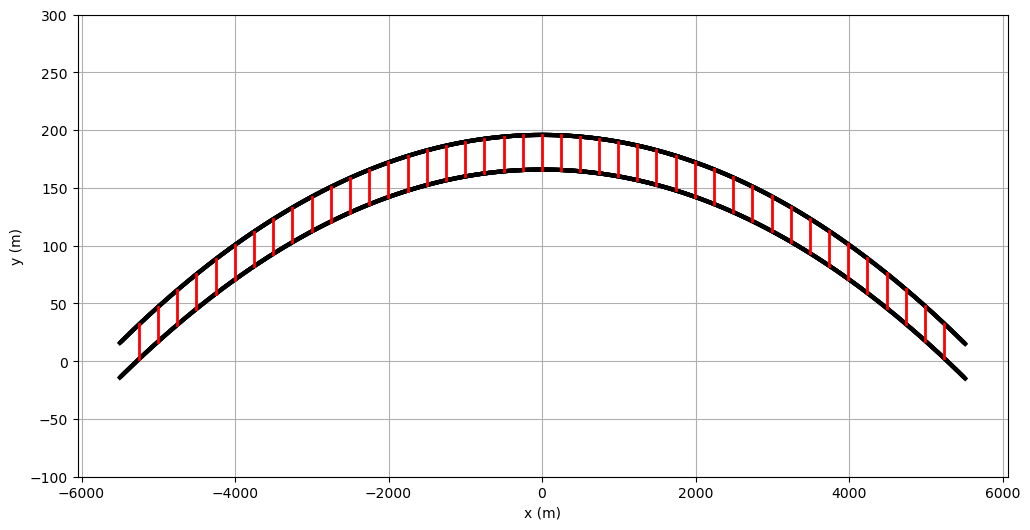

In [296]:
plt.figure(figsize=(12,6))

# -----------------------------
# Plot tunnel arches
# -----------------------------
for ele in Ele_tunnel_1 + Ele_tunnel_2:

    n1 = int(ele[0])
    n2 = int(ele[1])

    x1, y1, _ = NodeC[n1]
    x2, y2, _ = NodeC[n2]

    plt.plot(
        [x1, x2],
        [y1, y2],
        lw=3,
        color='k'
    )

# -----------------------------
# Plot escape routes
# -----------------------------
for ele in Ele_escape:

    n1 = int(ele[0])
    n2 = int(ele[1])

    x1, y1, _ = NodeC[n1]
    x2, y2, _ = NodeC[n2]

    plt.plot(
        [x1, x2],
        [y1, y2],
        lw=2,
        color='r'   # different color helps visualization
    )

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(-100, 300)
plt.grid(True)

plt.xlabel('x (m)')
plt.ylabel('y (m)')

plt.show()

In [297]:
mooring_spacing = 25.0  # [m]

NodeArr = np.array(NodeC, dtype=float)
nodeDiff = int(nNode / 2)

# Use tube 1 to determine positions along the tunnel
tube1 = NodeArr[:nodeDiff]

# Arc length along the tunnel
segment_lengths = np.linalg.norm(np.diff(tube1, axis=0), axis=1)
s = np.insert(np.cumsum(segment_lengths), 0, 0.0)

# Desired mooring positions every 25 m
target_s = np.arange(0.0, s[-1] + 0.5 * mooring_spacing, mooring_spacing)

# Find nearest FEM node to each mooring position
mooring_nodes_tube1 = np.unique([
    int(np.argmin(np.abs(s - target)))
    for target in target_s
])

# Optional: remove end nodes if they are already supported
mooring_nodes_tube1 = mooring_nodes_tube1[1:-1]

# Corresponding nodes on tube 2
mooring_nodes_tube2 = mooring_nodes_tube1 + nodeDiff

print("Mooring nodes tube 1:", mooring_nodes_tube1)
print("Mooring nodes tube 2:", mooring_nodes_tube2)
print("Number of moorings per tube:", len(mooring_nodes_tube1))

Mooring nodes tube 1: [  2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34  36
  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70  72
  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106 108
 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142 144
 146 148 150 152 154 156 158 160 162 164 166 168 170 172 174 176 178 180
 182 184 186 188 190 192 194 196 198 200 202 204 206 208 210 212 214 216
 218 220 222 224 226 228 230 232 234 236 238 240 242 244 246 248 250 252
 254 256 258 260 262 264 266 268 270 272 274 276 278 280 282 284 286 288
 290 292 294 296 298 300 302 304 306 308 310 312 314 316 318 320 322 324
 326 328 330 332 334 336 338 340 342 344 346 348 350 352 354 356 358 360
 362 364 366 368 370 372 374 376 378 380 382 384 386 388 390 392 394 396
 398 400 402 404 406 408 410 412 414 416 418 420 422 424 426 428 430 432
 434 436 438 440 442 444 446 448 450 452 454 456 458 460 462 464 466 468
 470 472 474 476 478 480 482 

## Define the shape functions

Here we will use **linear** shape functions for the **axial displacement** and **cubic** shape functions for the **deflection and rotations**. Since we already know its expression and we already have the value of the elemental matrices, we skip this step in this tutorial. 

## Computation of the elemental matrices

In the theory we have seen that the mass and stiffness elemental matrices for the space frame using linear and cubic shape functions are given by:

| <img width="50%" src="./img/nb09_f01_3Ddofs_nptel.png" /> |
| :---- |
| Fig 1: Definition of 3 dofs per node, for the 2 noded elements. (This is from my lectures slides. To Be replaced) |

$$ M = \frac{mL}{420} 
\begin{bmatrix} 
140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 156 & 0 & 0 & 0 & 22L & 0 & 54 & 0 & 0 & 0 & -13L \\ 
0 & 0 & 156 & 0 & 22L & 0 & 0 & 0 & 54 & 0 & 13L & 0 \\ 
0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 \\ 
0 & 0 & 22L & 0 & 4L^2 & 0 & 0 & 0 & -13L & 0 & -3L^2 & 0 \\ 
0 & 22L & 0 & 0 & 0 & 4L^2 & 0 & 13L & 0 & 0 & 0 & -3L^2 \\ 
70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 54 & 0 & 0 & 0 & 13L & 0 & 156 & 0 & 0 & 0 & -22L \\ 
0 & 0 & 54 & 0 & -13L & 0 & 0 & 0 & 156 & 0 & 22L & 0 \\ 
0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 \\ 
0 & 0 & 13L & 0 & -3L^2 & 0 & 0 & 0 & 22L & 0 & 4L^2 & 0 \\
0 & -13L & 0 & 0 & 0 & -3L^2 & 0 & -22L & 0 & 0 & 0 & 4L^2
\end{bmatrix} $$
$$ \quad K = 
\begin{bmatrix} 
\frac{EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{-EA}{L} &  0 & 0 & 0 & 0 & 0\\ 
0 & \frac{12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{-12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} \\ 
0 & 0 & \frac{12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{-12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & \frac{-6EI}{L^2} & 0 & \frac{4EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L} & 0 & \frac{-6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} \\ 
\frac{-EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{EA}{L} & 0 & 0 & 0 & 0 & 0 \\ 
0 & -\frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} \\ 
0 & 0 & -\frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{4EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L}
\end{bmatrix}$$

These matrices are used directly when calling the `BeamMatrices` function within the assembly process.

## Global assembly

The last step is to compute the global matrices and the global forcing vector. We start by initializing the global matrices as 1-dimensional arrays.

Then we loop over elements and perform all the elemental operations.

In [298]:
LDOF = 6
nDof = LDOF*nNode  #6 dof per node
K = np.zeros(nDof*nDof)
M = np.zeros(nDof*nDof)
Q = np.zeros(nDof*nDof)

from BeamMatrices2 import Beam3DMatrices

exeTime = [0.0, 0.0]
exeTime[0] = time.time()

for iEle in range(0, nEle):
    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    
    n1dof = LDOF*n1 + np.arange(0,LDOF)
    n2dof = LDOF*n2 + np.arange(0,LDOF)    
    
    # Calculate elemental matrices
    Me, Ke, Qe = Beam3DMatrices(m, EA, EIy, EIz, GJ, Im, (NodeC[n1], NodeC[n2]) )
    
    indexes = np.append(n1dof, n2dof)
    for i in range(0, 2*LDOF):
        for j in range(0, 2*LDOF):
            ij = indexes[i]*nDof + indexes[j]
            #print(ij)
            M[ij] = M[ij] + Me[i,j]
            K[ij] = K[ij] + Ke[i,j]
            Q[ij] = Q[ij] + Qe[i,j]

# Reshape the global matrix from a 1-dimensional array to a 2-dimensional array
M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))

exeTime[1] = time.time()
print("Execution time = ", exeTime[1] - exeTime[0], "s")

Execution time =  2.8925254344940186 s


In [345]:
# --------------------------------------------------
# Hydrodynamic added mass
# --------------------------------------------------

rho_w = 1025.0      # [kg/m3]
Cm = 1.0            # added mass coefficient [-]
D_outer = 12.7      # [m]

A_disp = np.pi * D_outer**2 / 4
m_added = rho_w * Cm * A_disp   # [kg/m]

M_added = m_added * Q

M = M + M_added

print("Added mass per meter:", round(m_added, 2), "kg/m")
print("Structural mass per meter:", round(Beam_m, 2), "kg/m")
print("Added/structural mass ratio:", round(m_added / Beam_m, 2))

Added mass per meter: 129843.79 kg/m
Structural mass per meter: 110000.0 kg/m
Added/structural mass ratio: 1.18


In [346]:
# from BeamMatrices3 import Beam3DMatrices, AddNodalSpring3D, AddDirectionalSpring3D
# kx_mooring = 800e3   # N/m
# kz_mooring = 60e3    # N/m

# for node in range(0, nEle):
#     K = AddNodalSpring3D(K, node, kx=kx_mooring, kz=kz_mooring, LDOF=LDOF)
#     K = AddNodalSpring3D(K, node + nodeDiff, kx=kx_mooring, kz=kz_mooring, LDOF=LDOF)

That completes the filling of the matrices. Let's have a look at the matrices' structure.

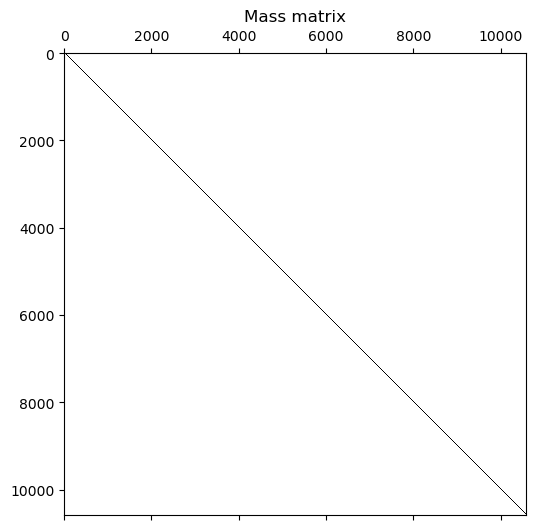

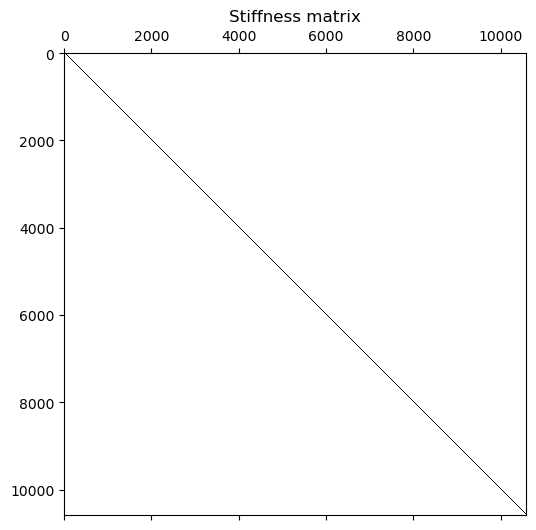

In [347]:
# Look at the matrix structure
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")
pass

In [348]:
# --------------------------------------------------
# Mooring stiffness from horizontal and vertical tangent stiffness
# --------------------------------------------------

def AddMooringSpringHV(K, node_id, kh, kv, LDOF=6):
    """
    Adds horizontal and vertical mooring tangent stiffness
    to one 3D beam node.

    DOF order per node:
    [ux, uy, uz, rx, ry, rz]

    kh = horizontal transverse stiffness [N/m]
    kv = vertical stiffness [N/m]
    """

    i = int(node_id) * LDOF

    K[i + 1, i + 1] += kh   # y-direction, horizontal transverse
    K[i + 2, i + 2] += kv   # z-direction, vertical

    return K

for i in range(0, len(mooring_nodes_tube1)):
    if i * 25 > 1000:               # First set of taut cables
        kh = 120e3
        kv = 46e3
        K = AddMooringSpringHV(K, mooring_nodes_tube1[i], kh, kv, LDOF=LDOF)
    elif 1000 <= i * 25 < 5500:     # First set of catenary cables
        kh= 120 + (400 - 120)/ 4500 * (i * 25 - 1000)
        kv= 46 + (61 - 46 )/ 4500 * (i * 25 - 1000)
        kh = kh*(10**3)
        kv = kv*(10**3)
        K = AddMooringSpringHV(K, mooring_nodes_tube1[i], kh, kv, LDOF=LDOF)

    elif 5500 <= i * 25 < 10000:    # Second set of catenary cables
        kh= 400 + (1200 - 400 )/ 4500 * (i * 25 - 5500)
        kv= 85 - (85 - 61 )/ 4500 * (i * 25 - 5500)
        kh = kh*(10**3)
        kv = kv*(10**3)
        K = AddMooringSpringHV(K, mooring_nodes_tube1[i], kh, kv, LDOF=LDOF)
    else:                           # Second set of taut cables
        kh = 1200e3
        kv = 85e3
        K = AddMooringSpringHV(K, mooring_nodes_tube1[i], kh, kv, LDOF=LDOF)






## Boundary conditions

To apply the boundary conditions, we will remove the rows associated to the fixed DOFs and add the contribution to the right-hand-side. First, we obtain the free and fixed DOFs.

In [349]:
NodesClamp = (0, int(round(nNode/2-1)), int(round(nNode/2)), nNode-1)

# Prescribed dofs
# Fixed Supports: ux=uy=uz=0 and rx=ry=rz=0 
# DofsP = np.empty([0], dtype=int)
# for n0 in NodesClamp:
#     DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

# Simple Supports: ux=uy=uz=0 and rx=ry=rz=Free 
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(
        DofsP,
        n0*LDOF + np.array([0,1,2])
    )
# Free dofs
DofsF = np.arange(0, nDof)       # free DOFs
DofsF = np.delete(DofsF, DofsP)  # remove the fixed DOFs from the free DOFs array

print(DofsP)
print(DofsF)

# M_FF = [ M[iRow,DofsF].tolist() for iRow in DofsF ]
# K_FF = [ K[iRow,DofsF].tolist() for iRow in DofsF ]
# Q_FF = [ Q[iRow,DofsF].tolist() for iRow in DofsF ]

M_FF = M[np.ix_(DofsF, DofsF)]
K_FF = K[np.ix_(DofsF, DofsF)]
Q_FF = Q[np.ix_(DofsF, DofsF)]

# plt.figure()
# plt.spy(M_FF)
# plt.title("Mass matrix")
# plt.figure()
# plt.spy(K_FF)
# plt.title("Stiffness matrix")
print("K shape:", K.shape)
print("K_FF shape:", K_FF.shape)
print("Number of prescribed DOFs:", len(DofsP))
print("Number of free DOFs:", len(DofsF))
pass

[    0     1     2  5286  5287  5288  5292  5293  5294 10578 10579 10580]
[    3     4     5 ... 10581 10582 10583]
K shape: (10584, 10584)
K_FF shape: (10572, 10572)
Number of prescribed DOFs: 12
Number of free DOFs: 10572


## Modal analysis

Using the matrices associated to the free DOFs, we can perform a modal analysis to get more information on how the structure will deform and determine the natural frequencies.

$$ ( K_{FF} - \omega^2 M_{FF} ) \phi = 0 $$

To compute the natural frequencies and mode shapes we use the `eig` command, which is part of the NumPy package. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [350]:
mat = np.dot(np.linalg.inv(M_FF), K_FF)
w2, vr = np.linalg.eig(mat)
w = np.sqrt(w2.real)
f = w/2/np.pi
print(len(f))


10572


C:\Users\lucwi\AppData\Local\Temp\ipykernel_22900\248324848.py:3: RuntimeWarning: invalid value encountered in sqrt
  w = np.sqrt(w2.real)


In [ ]:
idx = f.argsort()
f = f[idx]
vr = vr[:,idx]

print(f)
print("First 10 Natural frequencies (Hz) for", nNode, "nodes:")
print(f[854])

[0.00021755 0.00047415 0.00077654 ...        nan        nan        nan]
First 10 Natural frequencies (Hz) for 1764 nodes:
0.14809629902934904


: 

In [352]:
nMode = len(f)
print(nMode)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF,:] = vr

10572


In [353]:
# # Plotting mode shapes
# plt.figure()
# cmap = plt.colormaps.get_cmap('Accent')
# cmap = cmap.colors
# nCmap = len(cmap)

# nCol = 2
# nRow = int(np.floor(nMode/nCol))+1

# vMode1 = 1
# vMode2 = 8

# def plotEle(DisplacedNode):
#     for iElem in np.arange(0, nEle-1):
#         NodeLeft = int(round(Ele[iElem][0]))
#         NodeRight = int(round(Ele[iElem][1]))
#         if(iElem == 0):
#             plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
#                      [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap], 
#                      label = "Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz")
#         else:
#             plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
#                      [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap])


# # XY Plot
# for iMode in np.arange(vMode1, vMode2):    
#     Shape = ModalShape[:, iMode]

#     # Scale the mode such that maximum deformation is 10
#     MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
#     MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
#     MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
#     Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
#     Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
#     Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100    

#     # Get the deformed shape
#     DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF], 
#                      [i[1] + 300*np.floor(iMode/3) for i in NodeC] + Shape[1::LDOF])
    
#     plotEle(DisplacedNode)
#     plt.title("XY Plot")        
#     plt.grid('on')
#     plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
#           ncol=4, fancybox=True, shadow=True)    


# # XZ Plot
# plt.figure()
# for iMode in np.arange(vMode1, vMode2):    
#     Shape = ModalShape[:, iMode]

#     # Scale the mode such that maximum deformation is 10
#     MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
#     MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
#     MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
#     Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
#     Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
#     Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100

#     # Get the deformed shape
#     DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF],
#                      [i[2] + np.floor(iMode/3)*300 for i in NodeC] + Shape[2::LDOF])
    
#     plotEle(DisplacedNode)
#     plt.title("XZ Plot")    
#     plt.grid('on')
#     plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
#           ncol=4, fancybox=True, shadow=True)    
    


# pass

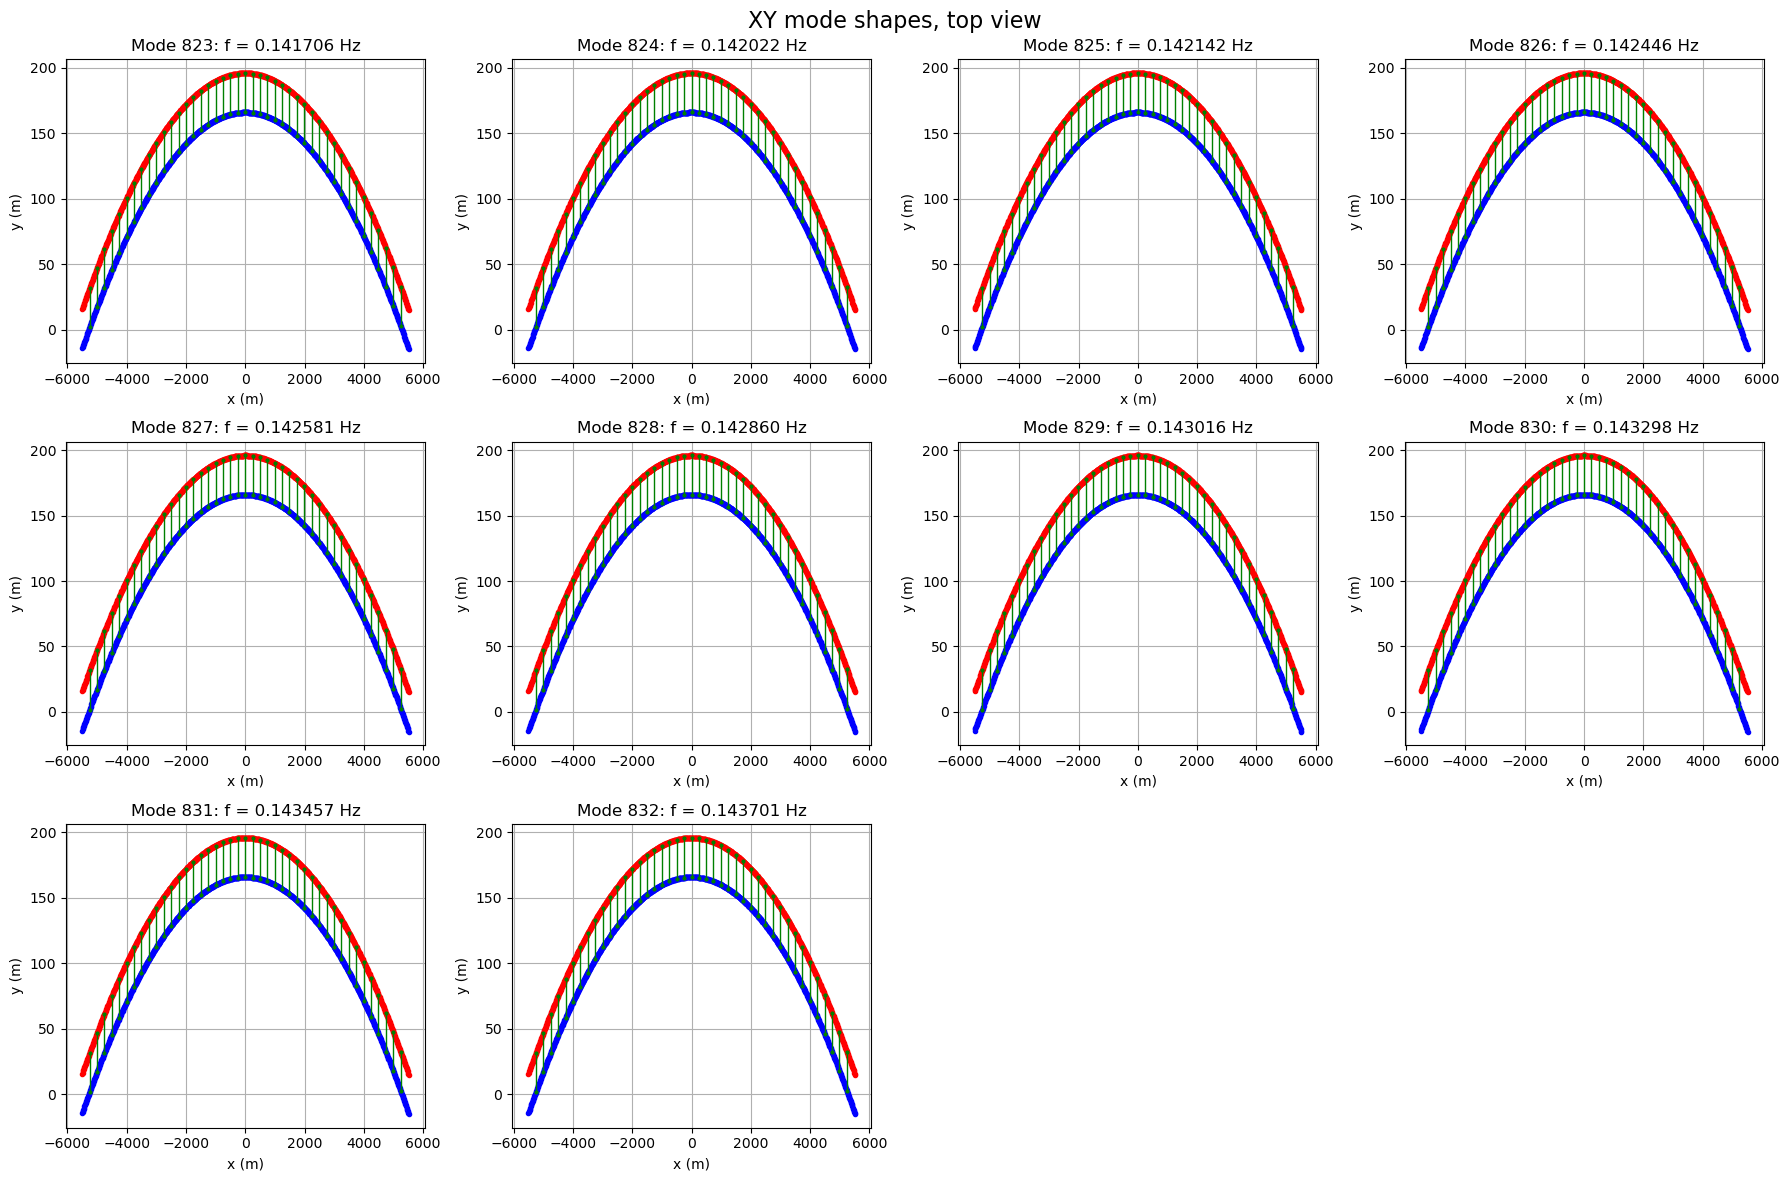

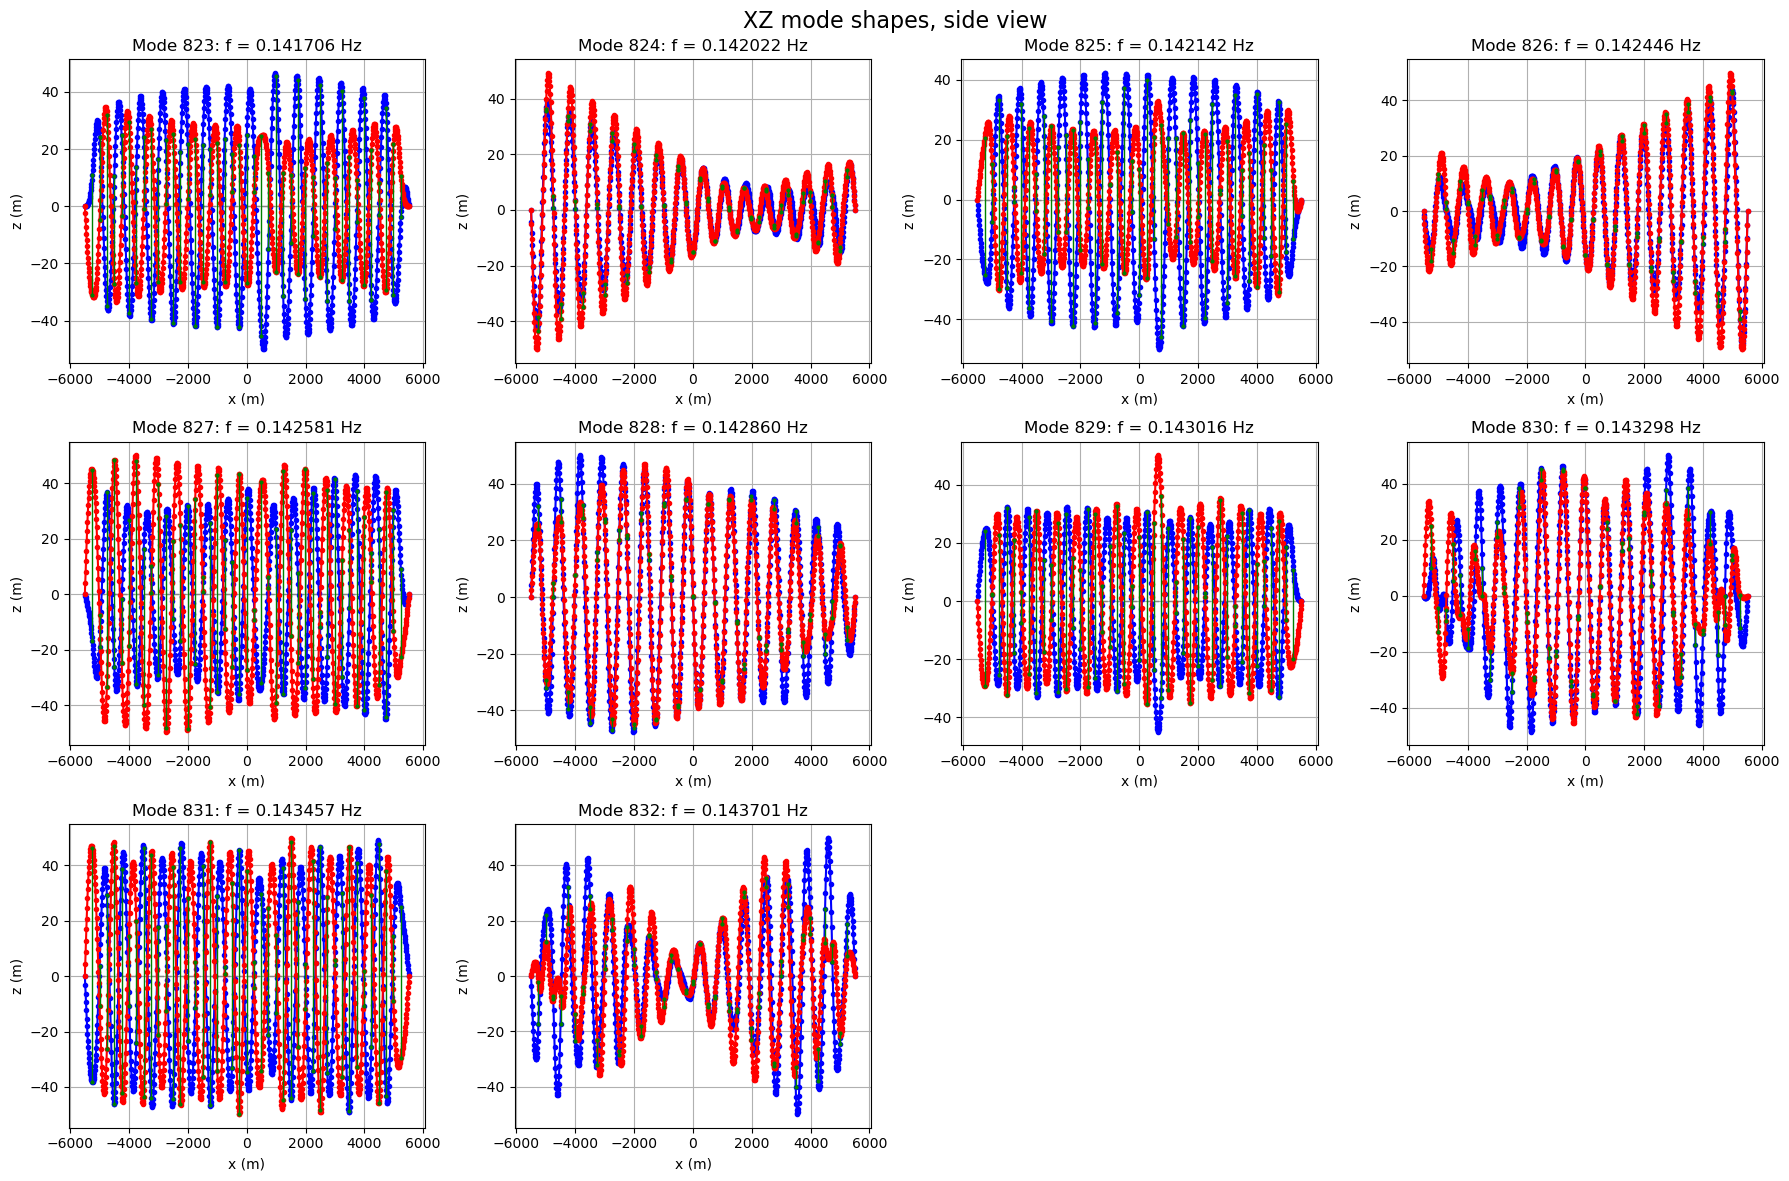

In [354]:
import numpy as np
import matplotlib.pyplot as plt

NodeArr = np.array(NodeC, dtype=float)

# Modes to plot
modes_to_plot = np.arange(823, 833)   # Mode 1 t/m 8

# Mesh split
nodeDiff = int(nNode / 2)

# Plot settings
scale = 50          # deformation scale, pas aan naar 20, 50, 100 etc.
ncols = 4
nrows = int(np.ceil(len(modes_to_plot) / ncols))

def mode_disp(iMode):
    """Extract translational mode-shape components."""
    phi = ModalShape[:, iMode]

    ux = phi[0::LDOF]
    uy = phi[1::LDOF]
    uz = phi[2::LDOF]

    # Normalize total displacement
    amp = np.max(np.sqrt(ux**2 + uy**2 + uz**2))
    if amp < 1e-12:
        return ux*0, uy*0, uz*0

    return ux / amp, uy / amp, uz / amp


def plot_mode_view(ax, iMode, view="XY"):
    ux, uy, uz = mode_disp(iMode)

    Xd = NodeArr[:, 0] + scale * ux
    Yd = NodeArr[:, 1] + scale * uy
    Zd = NodeArr[:, 2] + scale * uz

    # Choose plotting plane
    if view == "XY":
        a0, b0 = NodeArr[:, 0], NodeArr[:, 1]
        ad, bd = Xd, Yd
        ylabel = "y (m)"
    elif view == "XZ":
        a0, b0 = NodeArr[:, 0], NodeArr[:, 2]
        ad, bd = Xd, Zd
        ylabel = "z (m)"

    # Undeformed tunnel tubes
    ax.plot(a0[:nodeDiff], b0[:nodeDiff], "--", color="gray", lw=1, alpha=0.6)
    ax.plot(a0[nodeDiff:], b0[nodeDiff:], "--", color="gray", lw=1, alpha=0.6)

    # Deformed tunnel tubes
    ax.plot(ad[:nodeDiff], bd[:nodeDiff], "o-", color="blue", ms=3, lw=1.5,
            label="Tunnel 1")
    ax.plot(ad[nodeDiff:], bd[nodeDiff:], "o-", color="red", ms=3, lw=1.5,
            label="Tunnel 2")

    # Connectors / escape-route elements
    for iEle in range(nEle):
        n1 = int(round(Ele[iEle][0]))
        n2 = int(round(Ele[iEle][1]))

        # Only plot cross connections between the two tubes
        if abs(n2 - n1) == nodeDiff:
            ax.plot(
                [ad[n1], ad[n2]],
                [bd[n1], bd[n2]],
                color="green",
                lw=1,
                marker="o",
                ms=2
            )

    ax.set_title(f"Mode {iMode}: f = {f[iMode]:.6f} Hz")
    ax.set_xlabel("x (m)")
    ax.set_ylabel(ylabel)
    ax.grid(True)


# -----------------------------
# XY top view
# -----------------------------
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 4*nrows), sharex=False, sharey=False)
axs = axs.flatten()

for ax, iMode in zip(axs, modes_to_plot):
    plot_mode_view(ax, iMode, view="XY")

for ax in axs[len(modes_to_plot):]:
    ax.axis("off")

fig.suptitle("XY mode shapes, top view", fontsize=16)
plt.tight_layout()
plt.show()


# -----------------------------
# XZ side view
# -----------------------------
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 4*nrows), sharex=False, sharey=False)
axs = axs.flatten()

for ax, iMode in zip(axs, modes_to_plot):
    plot_mode_view(ax, iMode, view="XZ")

for ax in axs[len(modes_to_plot):]:
    ax.axis("off")

fig.suptitle("XZ mode shapes, side view", fontsize=16)
plt.tight_layout()
plt.show()
